# Extraction de Fissures via Frangi Graph Généralisé sur GPU (A100)
## Benchmark : CrackForest

Ce Colab implémente l'approche non supervisée pour le dataset **CrackForest**, exploitant la puissance du **GPU (PyTorch)** pour accélérer le filtrage Hessien et la construction du graphe de similarité.

Ici, nous n'utilisons qu'une **seule modalité** (le visible RGB converti en niveau de gris).

### Caractéristiques de l'implémentation :
- Chargement des données (.jpg pour l'image et .mat pour la Ground Truth).
- Calculs matriciels Hessiens et Valeurs Propres 100% sur GPU (`torch.Tensor`).
- Construction du graphe creux (Sparse) économe en VRAM.
- Algorithme d'extraction topologique (Arbre Couvrant de Poids Minimum + Centralité).
- **Analyse de sensibilité** des paramètres clés du graphe Généralisé.


In [1]:
!pip install -q scipy numpy matplotlib pandas gdown POT scikit-image tqdm

import os
import zipfile
from pathlib import Path

# Téléchargement du dataset CrackForest depuis GitHub
if not os.path.exists('CrackForest-dataset'):
    print("Téléchargement du dataset CrackForest depuis GitHub...")
    !git clone https://github.com/Ludwig-H/CrackForest-dataset.git
else:
    print("Dataset déjà présent.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.4 MB/s eta 0:00:00
Téléchargement du dataset CrackForest depuis GitHub...
Cloning into 'CrackForest-dataset'...
remote: Enumerating objects: 407, done.
remote: Total 407 (delta 0), reused 0 (delta 0), pack-reused 407 (from 1)
Receiving objects: 100% (407/407), 9.60 MiB | 33.79 MiB/s, done.
Resolving deltas: 100% (3/3), done.


## 1. Dataloader

Nous chargeons les 118 premières images et la vérité terrain associée (qui est déjà un squelette binaire dans la structure MATLAB).


In [2]:
import torch
import numpy as np
import cv2
import scipy.io as sio
from pathlib import Path
from torch.utils.data import Dataset
import matplotlib.pyplot as plt

class CrackForestDataset(Dataset):
    def __init__(self, root_dir):
        self.img_dir = Path(root_dir) / 'CrackForest-dataset' / 'image'
        self.gt_dir = Path(root_dir) / 'CrackForest-dataset' / 'groundTruth'

        # 118 premières images
        self.identifiants = [f"{i:03d}" for i in range(1, 119)]
        print(f"Dataset chargé avec {len(self.identifiants)} images.")

    def __len__(self):
        return len(self.identifiants)

    def __getitem__(self, idx):
        id_courant = self.identifiants[idx]

        path_img = self.img_dir / f"{id_courant}.jpg"
        path_gt  = self.gt_dir / f"{id_courant}.mat"

        # Chargement en N&B
        img_vis = cv2.imread(str(path_img), cv2.IMREAD_GRAYSCALE)

        # Normalisation
        vis_t = torch.from_numpy(img_vis).float() / 255.0

        # Chargement de la Ground Truth MATLAB
        mat = sio.loadmat(str(path_gt))
        # La structure du dataset contient 'Segmentation' ou 'Boundaries'
        # La vérité terrain est déjà squelettisée dans 'Boundaries', on extrait avec [0,0]['Boundaries']
        gt_data = mat['groundTruth'][0, 0]['Boundaries']

        # Binarisation stricte
        gt_clean = (gt_data > 0).astype(np.float32)
        gt_t = torch.from_numpy(gt_clean)

        return {
            'id': id_courant,
            'visible': vis_t,
            'gt': gt_t
        }

# Initialisation
dataset = CrackForestDataset('.')


Dataset chargé avec 118 images.


## 2. Calcul Hessien Multi-échelles sur GPU


In [3]:
import torch.nn.functional as F
import math

class FrangiHessianGPU:
    def __init__(self, scales, device='cuda' if torch.cuda.is_available() else 'cpu'):
        self.scales = scales
        self.device = device
        self.kernels = self._precompute_kernels()

    def _precompute_kernels(self):
        kernels = {}
        for s in self.scales:
            size = int(math.ceil(4 * s)) * 2 + 1
            x = torch.arange(-size // 2 + 1, size // 2 + 1, dtype=torch.float32, device=self.device)
            variance = s ** 2
            g_x = (1 / (math.sqrt(2 * math.pi) * s)) * torch.exp(-x**2 / (2 * variance))
            g_x_1 = -(x / variance) * g_x
            g_x_2 = ((x**2 / (variance**2)) - (1 / variance)) * g_x
            kernels[s] = {'0': g_x, '1': g_x_1, '2': g_x_2}
        return kernels

    def compute_hessian(self, image_tensor, s):
        if image_tensor.dim() == 2:
            image_tensor = image_tensor.unsqueeze(0).unsqueeze(0)

        image_tensor = image_tensor.to(self.device)

        k0 = self.kernels[s]['0'].view(1, 1, 1, -1)
        k1 = self.kernels[s]['1'].view(1, 1, 1, -1)
        k2 = self.kernels[s]['2'].view(1, 1, 1, -1)

        k0_T = k0.transpose(2, 3)
        k1_T = k1.transpose(2, 3)
        k2_T = k2.transpose(2, 3)

        pad_size = k0.shape[3] // 2

        def convolve_sep(x, k_h, k_v):
            p_h = F.pad(x, (pad_size, pad_size, 0, 0), mode='replicate')
            t = F.conv2d(p_h, k_h)
            p_v = F.pad(t, (0, 0, pad_size, pad_size), mode='replicate')
            return F.conv2d(p_v, k_v)

        ixx = convolve_sep(image_tensor, k2, k0_T)
        iyy = convolve_sep(image_tensor, k0, k2_T)
        ixy = convolve_sep(image_tensor, k1, k1_T)

        return ixx.squeeze(), ixy.squeeze(), iyy.squeeze()

    def compute_eigenvalues_and_vectors(self, ixx, ixy, iyy):
        trace = ixx + iyy
        disc = torch.sqrt((ixx - iyy)**2 + 4 * ixy**2)

        l_plus = (trace + disc) / 2
        l_minus = (trace - disc) / 2

        abs_l_plus = torch.abs(l_plus)
        abs_l_minus = torch.abs(l_minus)

        mask_minus_bigger = abs_l_minus > abs_l_plus

        λ2 = torch.where(mask_minus_bigger, l_minus, l_plus)
        λ1 = torch.where(mask_minus_bigger, l_plus, l_minus)

        θ = 0.5 * torch.atan2(2 * ixy, ixx - iyy)
        return λ1, λ2, θ


## 3. Construction du Graphe (Frangi Graph)

Application de la réponse Frangi et sparsification.


In [4]:
from scipy.sparse import coo_matrix

def extract_frangi_graph_gpu(imgs_dict, weights, Σ=[5.0], R=3,
                             ss=1.0, si=0.25, sa=0.3, τ=0.2, min_rel_size=150.0, device='cuda'):
    import time
    t0 = time.time()

    fh = FrangiHessianGPU(Σ, device=device)

    scale_data = []
    max_S_global = None
    H, W = None, None

    # 1. Fusion Multimodale par échelle
    for σ in Σ:
        fused_ixx = None

        for mod, w in weights.items():
            if w > 0:
                ixx, ixy, iyy = fh.compute_hessian(imgs_dict[mod], σ)
                if H is None:
                    H, W = ixx.shape

                trace = ixx + iyy
                disc = torch.sqrt((ixx - iyy)**2 + 4 * ixy**2)
                spectral_norm_local = (torch.abs(trace) + disc) / 2.0
                max_norm = torch.max(spectral_norm_local) + 1e-8

                if fused_ixx is None:
                    fused_ixx = w * (ixx / max_norm)
                    fused_ixy = w * (ixy / max_norm)
                    fused_iyy = w * (iyy / max_norm)
                else:
                    fused_ixx += w * (ixx / max_norm)
                    fused_ixy += w * (ixy / max_norm)
                    fused_iyy += w * (iyy / max_norm)

        λ1, λ2, θ = fh.compute_eigenvalues_and_vectors(fused_ixx, fused_ixy, fused_iyy)

        mask_pos = λ2 > 0
        R_B = torch.zeros_like(λ2)
        R_B[mask_pos] = torch.abs(λ1[mask_pos]) / (λ2[mask_pos] + 1e-8)

        S_norm = torch.zeros_like(λ2)
        S_norm[mask_pos] = λ2[mask_pos]

        if max_S_global is None: max_S_global = S_norm.clone()
        else: max_S_global = torch.max(max_S_global, S_norm)

        scale_data.append((R_B, S_norm, θ, mask_pos))

    if device == 'cuda': torch.cuda.synchronize()
    t_hessian = time.time()

    τ_1 = max_S_global.max() * 0.01
    candidates_mask = max_S_global > τ_1
    coords = torch.nonzero(candidates_mask).float()
    N = coords.shape[0]

    if N == 0:
        return np.zeros((H, W)), np.zeros((H, W)), np.zeros((H, W)), {}, {'tau_mask': np.zeros((H, W)), 'comp_mask': np.zeros((H, W))}

    index_map = torch.full((H, W), -1, dtype=torch.long, device=device)
    index_map[candidates_mask] = torch.arange(N, device=device)

    padded_index_map = torch.nn.functional.pad(index_map.unsqueeze(0).unsqueeze(0).float(), (R, R, R, R), value=-1).long()

    patches = padded_index_map[0, 0].unfold(0, 2*R+1, 1).unfold(1, 2*R+1, 1)

    y_coords, x_coords = torch.nonzero(candidates_mask, as_tuple=True)
    cand_patches = patches[y_coords, x_coords]

    dy, dx = torch.meshgrid(torch.arange(-R, R+1, device=device), torch.arange(-R, R+1, device=device), indexing='ij')
    dist_sq = dx**2 + dy**2
    valid_dist_mask = (dist_sq <= R**2) & (dist_sq > 0)
    half_mask = (dy > 0) | ((dy == 0) & (dx > 0))
    valid_mask = valid_dist_mask & half_mask

    valid_neighbors = cand_patches[:, valid_mask]

    source_idx = torch.arange(N, device=device).unsqueeze(1).expand(-1, valid_neighbors.shape[1])
    valid_pairs_mask = valid_neighbors != -1

    i_idx_t = source_idx[valid_pairs_mask]
    j_idx_t = valid_neighbors[valid_pairs_mask]

    if len(i_idx_t) == 0:
        return max_S_global.cpu().numpy(), np.zeros((H, W)), np.zeros((H, W)), {}, {'tau_mask': np.zeros((H, W)), 'comp_mask': np.zeros((H, W))}

    if device == 'cuda': torch.cuda.synchronize()
    t_unfold = time.time()

    S_ij_max = torch.zeros(len(i_idx_t), device=device, dtype=torch.float32)

    for R_B, S_norm, θ, mask_pos in scale_data:
        rb_c = R_B[candidates_mask]
        s_c  = S_norm[candidates_mask]
        t_c  = θ[candidates_mask]

        rb_sum = rb_c[i_idx_t] + rb_c[j_idx_t]
        S_shape = torch.exp(-0.5 * (rb_sum / ss)**2)

        s_prod = s_c[i_idx_t] * s_c[j_idx_t]
        S_int = 1 - torch.exp(-0.5 * (s_prod / si)**2)

        dt = t_c[i_idx_t] - t_c[j_idx_t]
        S_align = torch.exp(-0.5 * (torch.sin(dt) / sa)**2)

        S_ij = S_shape * S_int * S_align
        S_ij_max = torch.max(S_ij_max, S_ij)

    if device == 'cuda': torch.cuda.synchronize()
    t_sim = time.time()

    dist_ij_t = torch.norm(coords[i_idx_t] - coords[j_idx_t], dim=1)
    d_ij = (1 - S_ij_max) * dist_ij_t + 1e-8

    S_cpu = S_ij_max.cpu().numpy()
    d_cpu = d_ij.cpu().numpy()
    i_cpu = i_idx_t.cpu().numpy()
    j_cpu = j_idx_t.cpu().numpy()

    import numpy as np
    from scipy.sparse.csgraph import minimum_spanning_tree, breadth_first_order, connected_components

    num_edges = len(S_cpu)
    num_to_keep_edges = max(1, int(num_edges * τ))

    if num_edges > num_to_keep_edges:
        threshold_edge = np.partition(S_cpu, -num_to_keep_edges)[-num_to_keep_edges]
        edge_mask = S_cpu >= threshold_edge
    else:
        edge_mask = np.ones(num_edges, dtype=bool)

    i_v = i_cpu[edge_mask]
    j_v = j_cpu[edge_mask]
    S_v = S_cpu[edge_mask]
    d_v = d_cpu[edge_mask]

    node_sim_max = np.zeros(N, dtype=np.float32)
    if len(S_v) > 0:
        np.maximum.at(node_sim_max, i_v, S_v)
        np.maximum.at(node_sim_max, j_v, S_v)

    N_total = H * W
    num_to_keep_nodes = max(1, int(N_total * τ))

    valid_nodes_candidates = np.unique(np.concatenate([i_v, j_v])) if len(i_v) > 0 else np.array([], dtype=np.int32)

    if len(valid_nodes_candidates) > num_to_keep_nodes:
        sims_candidates = node_sim_max[valid_nodes_candidates]
        threshold_node = np.partition(sims_candidates, -num_to_keep_nodes)[-num_to_keep_nodes]
        valid_nodes = valid_nodes_candidates[sims_candidates >= threshold_node]
    else:
        valid_nodes = valid_nodes_candidates

    if len(valid_nodes) > 0 and len(i_v) > 0:
        keep_node_mask = np.zeros(N, dtype=bool)
        keep_node_mask[valid_nodes] = True

        final_edge_mask = keep_node_mask[i_v] & keep_node_mask[j_v]
        i_v = i_v[final_edge_mask]
        j_v = j_v[final_edge_mask]
        S_v = S_v[final_edge_mask]
        d_v = d_v[final_edge_mask]
    else:
        i_v, j_v, S_v, d_v = np.array([]), np.array([]), np.array([]), np.array([])

    remap = np.full(N, -1, dtype=np.int32)
    remap[valid_nodes] = np.arange(len(valid_nodes))

    i_mapped = remap[i_v]
    j_mapped = remap[j_v]

    orig_coords_cpu = coords.cpu().numpy().astype(int)
    coords = coords[valid_nodes]
    N_valid = len(valid_nodes)

    S_sparse = coo_matrix((np.concatenate([S_v, S_v]),
                           (np.concatenate([i_mapped, j_mapped]), np.concatenate([j_mapped, i_mapped]))),
                          shape=(N_valid, N_valid)).tocsr()

    sparse_dist = coo_matrix((np.concatenate([d_v, d_v]),
                              (np.concatenate([i_mapped, j_mapped]), np.concatenate([j_mapped, i_mapped]))),
                             shape=(N_valid, N_valid)).tocsr()

    n_comp, labels = connected_components(sparse_dist, directed=False)
    counts = np.bincount(labels)

    min_size = N_total / min_rel_size
    valid_components = np.where(counts > min_size)[0]

    cent_img = np.zeros((H, W), dtype=np.float32)
    comp_mask = np.zeros((H, W), dtype=np.float32)
    tau_mask = np.zeros((H, W), dtype=np.float32)
    tau_mask[orig_coords_cpu[valid_nodes, 0], orig_coords_cpu[valid_nodes, 1]] = 1.0

    if len(valid_components) > 0:
        t_mst = 0
        t_bet_start = time.time()

        for comp_id in valid_components:
            mask_comp = (labels == comp_id)
            nodes_comp = np.where(mask_comp)[0]

            sparse_dist_comp = sparse_dist[nodes_comp, :][:, nodes_comp]
            S_sparse_comp = S_sparse[nodes_comp, :][:, nodes_comp]

            t_mst_start = time.time()
            mst = minimum_spanning_tree(sparse_dist_comp)
            order, preds = breadth_first_order(mst, i_start=0, directed=False, return_predecessors=True)
            t_mst += (time.time() - t_mst_start)

            N_L = len(nodes_comp)
            valid_mask_preds = preds >= 0
            p_valid = preds[valid_mask_preds]
            i_valid = np.arange(N_L)[valid_mask_preds]

            W_parent_np = np.zeros(N_L, dtype=np.float32)

            S_coo_comp = S_sparse_comp.tocoo()
            weights_dict = {(r, c): v for r, c, v in zip(S_coo_comp.row, S_coo_comp.col, S_coo_comp.data)}
            for idx, (p, i) in enumerate(zip(p_valid, i_valid)):
                W_parent_np[i] = weights_dict.get((p, i), 0.0)

            E_mass_np = np.zeros(N_L, dtype=np.float32)

            for i in order[::-1]:
                p = preds[i]
                if p >= 0:
                    E_mass_np[p] += E_mass_np[i] + W_parent_np[i]

            M_total = E_mass_np[order[0]]

            W_parent = torch.tensor(W_parent_np, dtype=torch.float32, device=device)
            E_mass = torch.tensor(E_mass_np, dtype=torch.float32, device=device)

            child_branch_mass = W_parent + E_mass
            p_valid_t = torch.tensor(p_valid, dtype=torch.long, device=device)
            i_valid_t = torch.tensor(i_valid, dtype=torch.long, device=device)

            sum_masses_children = torch.zeros(N_L, dtype=torch.float32, device=device)
            sum_masses_children.index_add_(0, p_valid_t, child_branch_mass[i_valid_t])

            parent_branch_mass = torch.clamp(M_total - sum_masses_children, min=0.0)

            val_child = child_branch_mass * (M_total - child_branch_mass)
            sum_val_child = torch.zeros(N_L, dtype=torch.float32, device=device)
            sum_val_child.index_add_(0, p_valid_t, val_child[i_valid_t])

            val_parent = parent_branch_mass * (M_total - parent_branch_mass)
            centrality = (sum_val_child + val_parent) / 2.0

            if centrality.max() > 0:
                centrality /= centrality.max()

            coords_comp = coords[nodes_comp].cpu().numpy().astype(int)
            cent_img[coords_comp[:, 0], coords_comp[:, 1]] = centrality.cpu().numpy()
            comp_mask[coords_comp[:, 0], coords_comp[:, 1]] = 1.0

        if device == 'cuda': torch.cuda.synchronize()
        t_mst_total = t_mst
        t_bet_total = time.time() - t_bet_start - t_mst_total
    else:
        t_mst_total = 0
        t_bet_total = 0

    sim_img = np.zeros((H, W), dtype=np.float32)
    sim_img[orig_coords_cpu[:, 0], orig_coords_cpu[:, 1]] = node_sim_max

    if device == 'cuda': torch.cuda.synchronize()
    t_end = time.time()

    timings = {
        "1. Hessian Fusion": t_hessian - t0,
        "2. Graph Unfold": t_unfold - t_hessian,
        "3. Frangi Similarity": t_sim - t_unfold,
        "4. MST (CPU)": t_mst_total,
        "5. Betweenness (GPU)": t_bet_total,
        "Total": t_end - t0
    }

    return max_S_global.cpu().numpy(), sim_img, cent_img, timings, {'tau_mask': tau_mask, 'comp_mask': comp_mask}


## 4. Visualisation sur un échantillon CrackForest


--- Metrics for sample: 001 ---
Jaccard (IoU): 0.6958
Tversky:       0.7420
Wasserstein:   3.6490


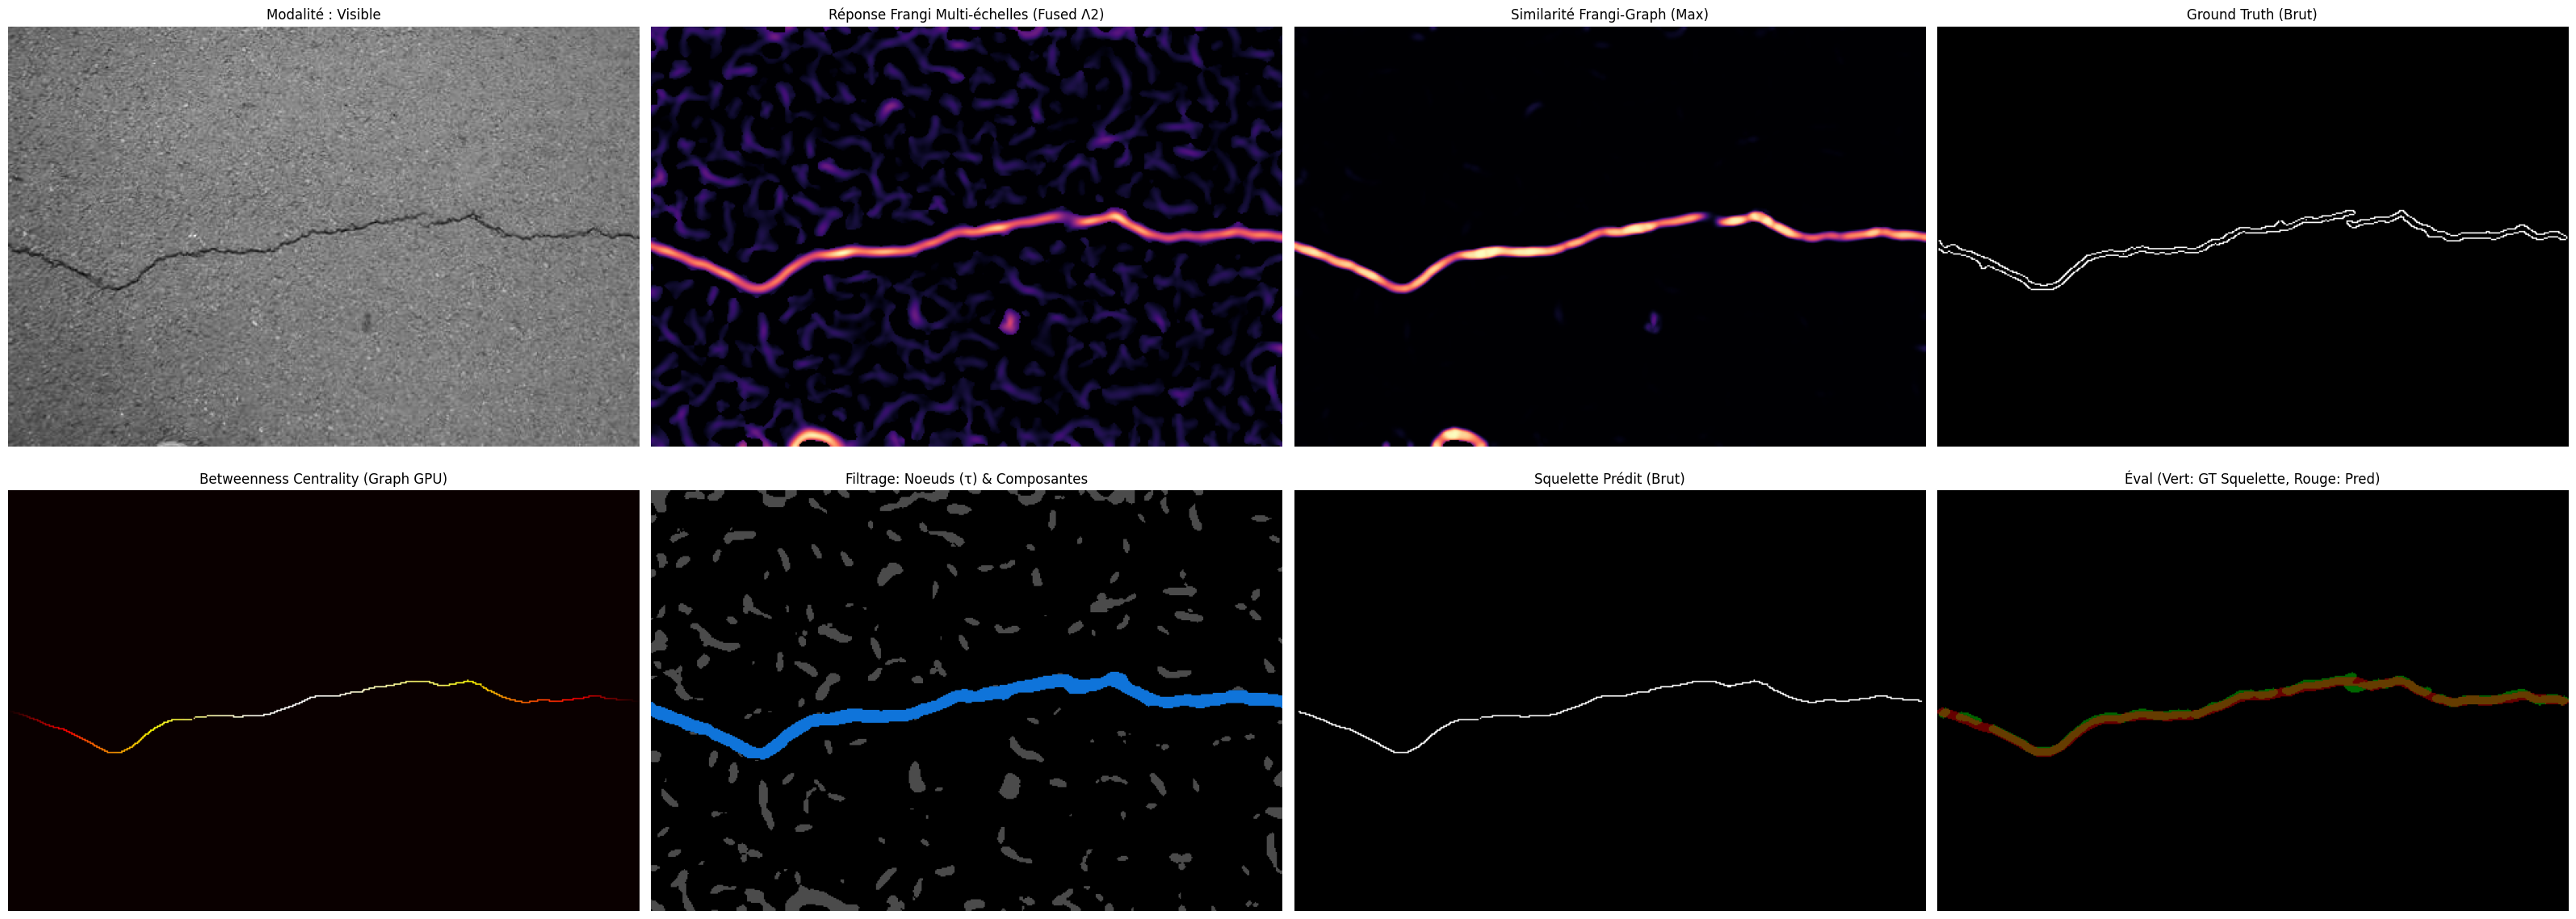

In [7]:
import ot
from skimage.morphology import skeletonize, disk, dilation
import warnings

def skeletonize_lee(binary_mask: np.ndarray) -> np.ndarray:
    import cv2
    m = (binary_mask > 0).astype(np.uint8)

    # Lissage morphologique pour gommer les irrégularités de contour
    # (cela élimine la grande majorité des petites branches parasites du squelette)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, kernel)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, kernel)

    sk = skeletonize(m>0)
    return sk.astype(np.uint8)

def thicken(skel: np.ndarray, pixels: int = 3) -> np.ndarray:
    if pixels <= 1: return skel.astype(np.uint8)
    import cv2
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (pixels*2+1, pixels*2+1))
    thick = cv2.dilate((skel>0).astype(np.uint8), kernel)
    return thick

def compute_metrics(pred_mask, gt_mask):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    A = pred_mask.clone().detach().bool().to(device) if isinstance(pred_mask, torch.Tensor) else torch.from_numpy(pred_mask).bool().to(device)
    B = gt_mask.clone().detach().bool().to(device) if isinstance(gt_mask, torch.Tensor) else torch.from_numpy(gt_mask).bool().to(device)

    inter = (A & B).sum().float()
    union = (A | B).sum().float()
    jaccard = (inter / (union + 1e-9)).item()

    not_A = ~A
    not_B = ~B
    fp = (not_A & B).sum().float()
    fn = (A & not_B).sum().float()
    tversky = (inter / (inter + 1.0 * fn + 0.5 * fp + 1e-9)).item()

    return jaccard, tversky

def wasserstein_distance_skeletons(A, B, max_samples: int = 2000) -> float:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    A_t = A.clone().detach().to(device) if isinstance(A, torch.Tensor) else torch.from_numpy(A).to(device)
    B_t = B.clone().detach().to(device) if isinstance(B, torch.Tensor) else torch.from_numpy(B).to(device)

    A_pts = torch.nonzero(A_t > 0).float()
    B_pts = torch.nonzero(B_t > 0).float()

    na, nb = A_pts.shape[0], B_pts.shape[0]

    if na == 0 and nb == 0: return 0.0
    if na == 0: return float(nb)
    if nb == 0: return float(na)

    if na > max_samples:
        idx = torch.randperm(na, device=device)[:max_samples]
        A_pts = A_pts[idx]
        na = max_samples

    if nb > max_samples:
        idx = torch.randperm(nb, device=device)[:max_samples]
        B_pts = B_pts[idx]
        nb = max_samples

    M_t = torch.cdist(A_pts, B_pts, p=2.0)

    M = M_t.cpu().numpy().astype(np.float64)
    a = np.ones((na,), dtype=np.float64) / float(na)
    b = np.ones((nb,), dtype=np.float64) / float(nb)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        emd_cost = ot.emd2(a, b, M)

    return float(emd_cost)

# Prendre un échantillon
sample = dataset[0] # e.g. LAB00030 (ici CrackForest 011)
imgs = {'visible': sample['visible']}
weights = {'visible': 1.0}

device = 'cuda' if torch.cuda.is_available() else 'cpu'
frangi_response, similarity_img, centrality, timings, diagnostics = extract_frangi_graph_gpu(imgs, weights, device=device)

skeleton = (centrality > 0.025).astype(np.float32)

gt_arr_sample = sample['gt'].numpy().astype(np.uint8)
sk_gt_sample = skeletonize_lee(gt_arr_sample)
sk_gt_thick_sample = thicken(sk_gt_sample, pixels=3)

pred_sample = skeleton.astype(np.uint8)
sk_pred_thick_sample = thicken(pred_sample, pixels=3)

j_sample, t_sample = compute_metrics(sk_pred_thick_sample, sk_gt_thick_sample)
w_sample = wasserstein_distance_skeletons(sk_pred_thick_sample, sk_gt_thick_sample)

print(f"--- Metrics for sample: {sample['id']} ---")
print(f"Jaccard (IoU): {j_sample:.4f}")
print(f"Tversky:       {t_sample:.4f}")
print(f"Wasserstein:   {w_sample:.4f}")

fig, axes = plt.subplots(2, 4, figsize=(32, 12))

axes[0, 0].imshow(sample['visible'].numpy(), cmap='gray')
axes[0, 0].set_title('Modalité : Visible')

axes[0, 1].imshow(frangi_response, cmap='magma')
axes[0, 1].set_title('Réponse Frangi Multi-échelles (Fused Λ2)')

axes[0, 2].imshow(similarity_img, cmap='magma')
axes[0, 2].set_title('Similarité Frangi-Graph (Max)')

axes[0, 3].imshow(sample['gt'].numpy(), cmap='gray')
axes[0, 3].set_title('Ground Truth (Brut)')

axes[1, 0].imshow(centrality, cmap='hot')
axes[1, 0].set_title('Betweenness Centrality (Graph GPU)')

axes[1, 1].imshow(np.zeros_like(skeleton), cmap='gray')
h, w = skeleton.shape
rgba_tau = np.zeros((h, w, 4), dtype=np.float32)
rgba_tau[diagnostics['tau_mask'] > 0] = [1.0, 1.0, 1.0, 0.3]
rgba_comp = np.zeros((h, w, 4), dtype=np.float32)
rgba_comp[diagnostics['comp_mask'] > 0] = [0.0, 0.5, 1.0, 0.8]
axes[1, 1].imshow(rgba_tau)
axes[1, 1].imshow(rgba_comp)
axes[1, 1].set_title('Filtrage: Noeuds (τ) & Composantes')

axes[1, 2].imshow(skeleton, cmap='gray')
axes[1, 2].set_title('Squelette Prédit (Brut)')

axes[1, 3].imshow(np.zeros_like(skeleton), cmap='gray')
rgba_gt_skel = np.zeros((h, w, 4), dtype=np.float32)
rgba_gt_skel[sk_gt_thick_sample > 0] = [0.0, 1.0, 0.0, 0.4] # Vert transparent

rgba_pred = np.zeros((h, w, 4), dtype=np.float32)
rgba_pred[sk_pred_thick_sample > 0] = [1.0, 0.0, 0.0, 0.4] # Rouge transparent

axes[1, 3].imshow(rgba_gt_skel)
axes[1, 3].imshow(rgba_pred)
axes[1, 3].set_title('Éval (Vert: GT Squelette, Rouge: Pred)')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()


## 5. Analyse de sensibilité des paramètres

Nous allons faire varier paramètre par paramètre : `R, ss, si, sa, τ`, `τ_c` (le seuil de centralité), `min_rel_size` (taille relative minimale d'une composante) et `Σ` (réduit à `σ_0`).
Les autres paramètres resteront constants.

Nous chargeons d'abord le dataset en RAM pour une exécution ultra-rapide.


Chargement complet des 118 images en RAM pour accélérer l'analyse de sensibilité...
Terminé.

--- Analyse de sensibilité pour R ---


[R = 1] évalué en 97.92s : Jaccard=0.4502±0.2038 | Tversky=0.5146±0.2086 | Wasserstein=183.1386±719.1084


[R = 2] évalué en 102.03s : Jaccard=0.4620±0.1937 | Tversky=0.5267±0.1963 | Wasserstein=116.0207±587.6729


[R = 3] évalué en 109.81s : Jaccard=0.4700±0.1861 | Tversky=0.5342±0.1877 | Wasserstein=95.2404±548.1236


[R = 4] évalué en 117.77s : Jaccard=0.4757±0.1824 | Tversky=0.5371±0.1841 | Wasserstein=93.1632±548.2290


...

[R = 6] évalué en 147.04s : Jaccard=0.4879±0.1764 | Tversky=0.5430±0.1796 | Wasserstein=37.6089±29.6723


[R = 7] évalué en 162.41s : Jaccard=0.4864±0.1728 | Tversky=0.5383±0.1786 | Wasserstein=38.4092±29.2085


[R = 8] évalué en 179.19s : Jaccard=0.4786±0.1726 | Tversky=0.5256±0.1807 | Wasserstein=39.8344±30.9080


[R = 9] évalué en 203.29s : Jaccard=0.4561±0.1684 | Tversky=0.4966±0.1778 | Wasserstein=45.0864±32.0820


[R = 10] évalué en 226.68s : Jaccard=0.4254±0.1598 | Tversky=0.4591±0.1711 | Wasserstein=50.7106±32.0476
--- Fin de l'analyse pour R (Temps total : 1477.82s) ---


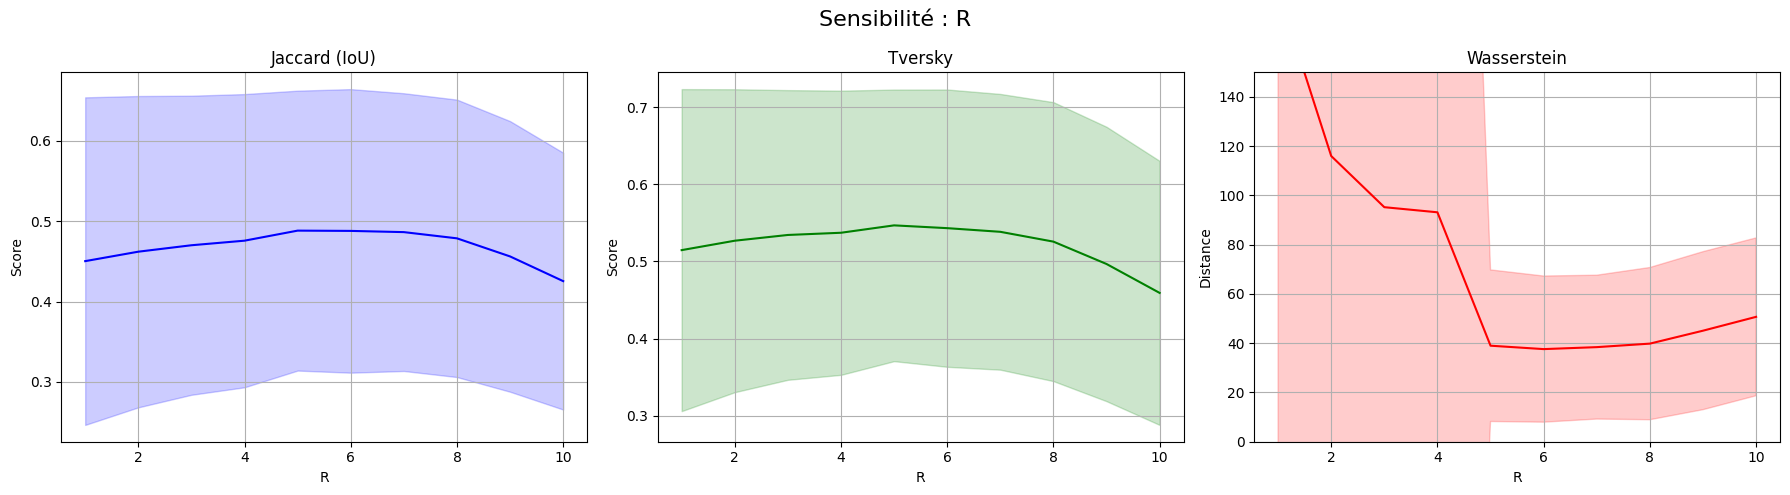


--- Analyse de sensibilité pour ss ---


[ss = 0.5] évalué en 130.93s : Jaccard=0.4766±0.1715 | Tversky=0.5404±0.1713 | Wasserstein=42.0550±33.1698


[ss = 0.7222222222222222] évalué en 131.10s : Jaccard=0.4841±0.1771 | Tversky=0.5443±0.1773 | Wasserstein=39.1875±31.7614


[ss = 0.9444444444444444] évalué en 132.49s : Jaccard=0.4879±0.1755 | Tversky=0.5462±0.1771 | Wasserstein=39.2838±31.3244


[ss = 1.1666666666666665] évalué en 132.42s : Jaccard=0.4874±0.1735 | Tversky=0.5452±0.1759 | Wasserstein=39.1845±30.0817


...

[ss = 1.6111111111111112] évalué en 132.85s : Jaccard=0.4869±0.1736 | Tversky=0.5439±0.1767 | Wasserstein=39.3527±30.5424


[ss = 1.8333333333333333] évalué en 133.09s : Jaccard=0.4863±0.1746 | Tversky=0.5433±0.1776 | Wasserstein=39.1019±31.4444


[ss = 2.0555555555555554] évalué en 133.32s : Jaccard=0.4857±0.1745 | Tversky=0.5427±0.1775 | Wasserstein=39.0531±30.8106


[ss = 2.2777777777777777] évalué en 132.47s : Jaccard=0.4858±0.1743 | Tversky=0.5428±0.1774 | Wasserstein=38.6852±30.5643


[ss = 2.5] évalué en 132.63s : Jaccard=0.4855±0.1744 | Tversky=0.5424±0.1777 | Wasserstein=38.8513±30.9416
--- Fin de l'analyse pour ss (Temps total : 1323.55s) ---


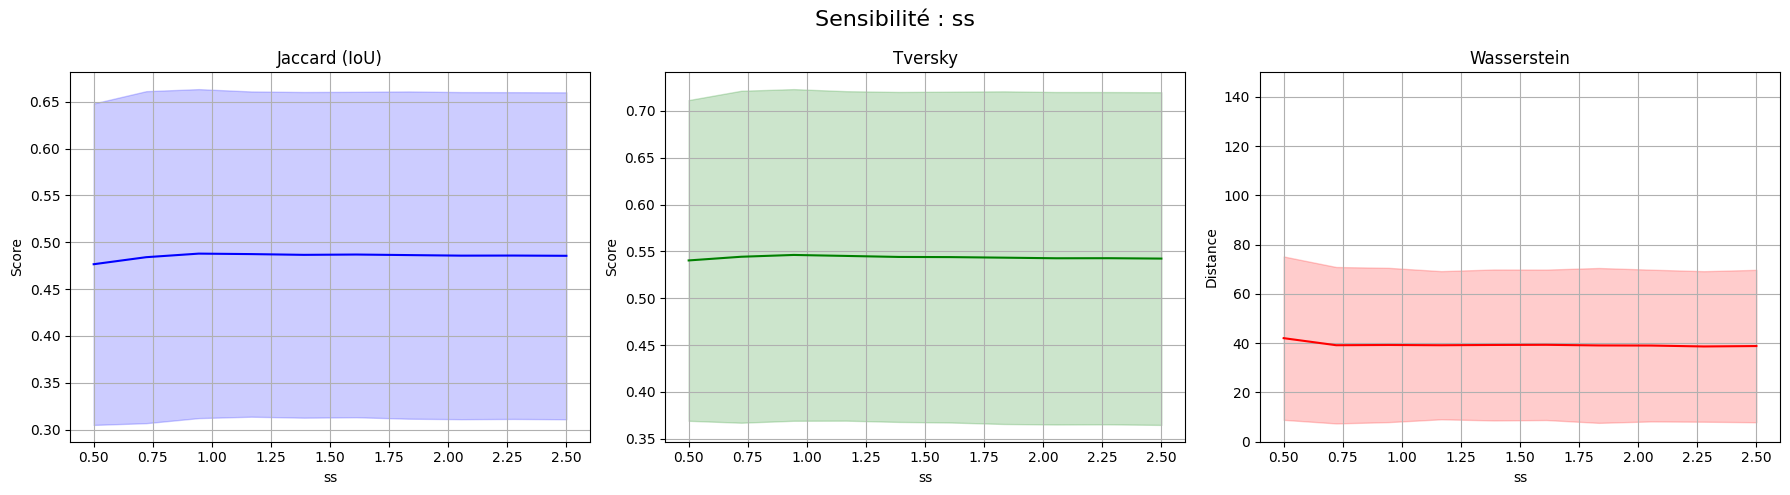


--- Analyse de sensibilité pour si ---


[si = 0.1] évalué en 131.06s : Jaccard=0.4669±0.1631 | Tversky=0.5169±0.1642 | Wasserstein=39.4205±30.7964


[si = 0.18888888888888888] évalué en 132.10s : Jaccard=0.4847±0.1738 | Tversky=0.5411±0.1754 | Wasserstein=39.2169±31.2228


[si = 0.2777777777777778] évalué en 131.67s : Jaccard=0.4885±0.1745 | Tversky=0.5475±0.1763 | Wasserstein=39.1846±31.0213


[si = 0.3666666666666667] évalué en 131.50s : Jaccard=0.4876±0.1746 | Tversky=0.5477±0.1767 | Wasserstein=39.4388±30.6120


...

[si = 0.5444444444444445] évalué en 132.69s : Jaccard=0.4868±0.1754 | Tversky=0.5479±0.1778 | Wasserstein=39.7141±30.8937


[si = 0.6333333333333333] évalué en 132.18s : Jaccard=0.4867±0.1751 | Tversky=0.5481±0.1775 | Wasserstein=39.8478±31.3979


[si = 0.7222222222222222] évalué en 132.89s : Jaccard=0.4865±0.1751 | Tversky=0.5480±0.1775 | Wasserstein=39.8883±31.4639


[si = 0.8111111111111111] évalué en 132.13s : Jaccard=0.4863±0.1749 | Tversky=0.5480±0.1774 | Wasserstein=39.9245±31.3091


[si = 0.9] évalué en 132.57s : Jaccard=0.4862±0.1748 | Tversky=0.5480±0.1773 | Wasserstein=40.0691±31.2974
--- Fin de l'analyse pour si (Temps total : 1320.94s) ---


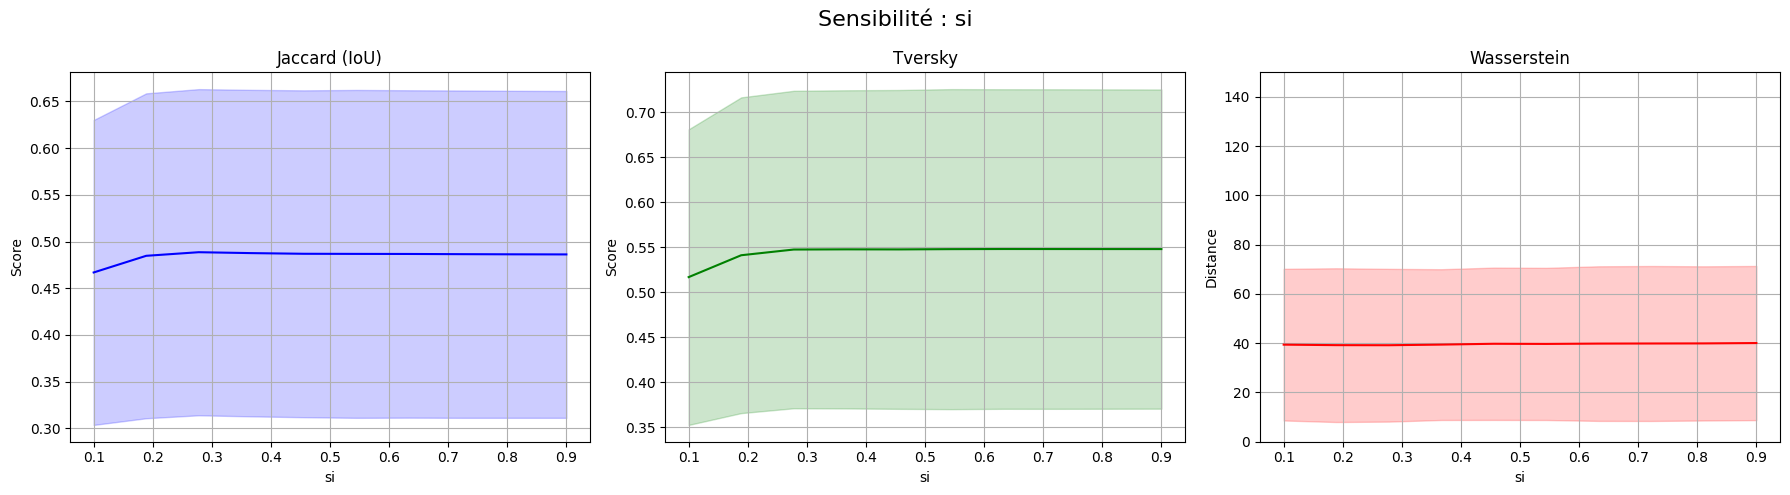


--- Analyse de sensibilité pour sa ---


[sa = 0.1] évalué en 128.01s : Jaccard=0.4797±0.1737 | Tversky=0.5345±0.1773 | Wasserstein=38.8085±30.5940


[sa = 0.17777777777777778] évalué en 129.96s : Jaccard=0.4843±0.1751 | Tversky=0.5422±0.1778 | Wasserstein=39.4956±30.5521


[sa = 0.25555555555555554] évalué en 131.11s : Jaccard=0.4873±0.1745 | Tversky=0.5453±0.1765 | Wasserstein=38.5780±30.6258


[sa = 0.33333333333333337] évalué en 131.52s : Jaccard=0.4877±0.1734 | Tversky=0.5463±0.1755 | Wasserstein=38.9458±30.8702


...

[sa = 0.48888888888888893] évalué en 131.92s : Jaccard=0.4849±0.1755 | Tversky=0.5430±0.1770 | Wasserstein=39.2693±31.7803


[sa = 0.5666666666666667] évalué en 131.83s : Jaccard=0.4841±0.1752 | Tversky=0.5420±0.1768 | Wasserstein=40.0731±31.7894


[sa = 0.6444444444444445] évalué en 131.66s : Jaccard=0.4841±0.1754 | Tversky=0.5415±0.1770 | Wasserstein=39.9080±31.5818


[sa = 0.7222222222222222] évalué en 131.85s : Jaccard=0.4855±0.1766 | Tversky=0.5426±0.1783 | Wasserstein=39.5892±31.4765


[sa = 0.8] évalué en 132.52s : Jaccard=0.4860±0.1761 | Tversky=0.5428±0.1780 | Wasserstein=39.0388±31.6025
--- Fin de l'analyse pour sa (Temps total : 1311.00s) ---


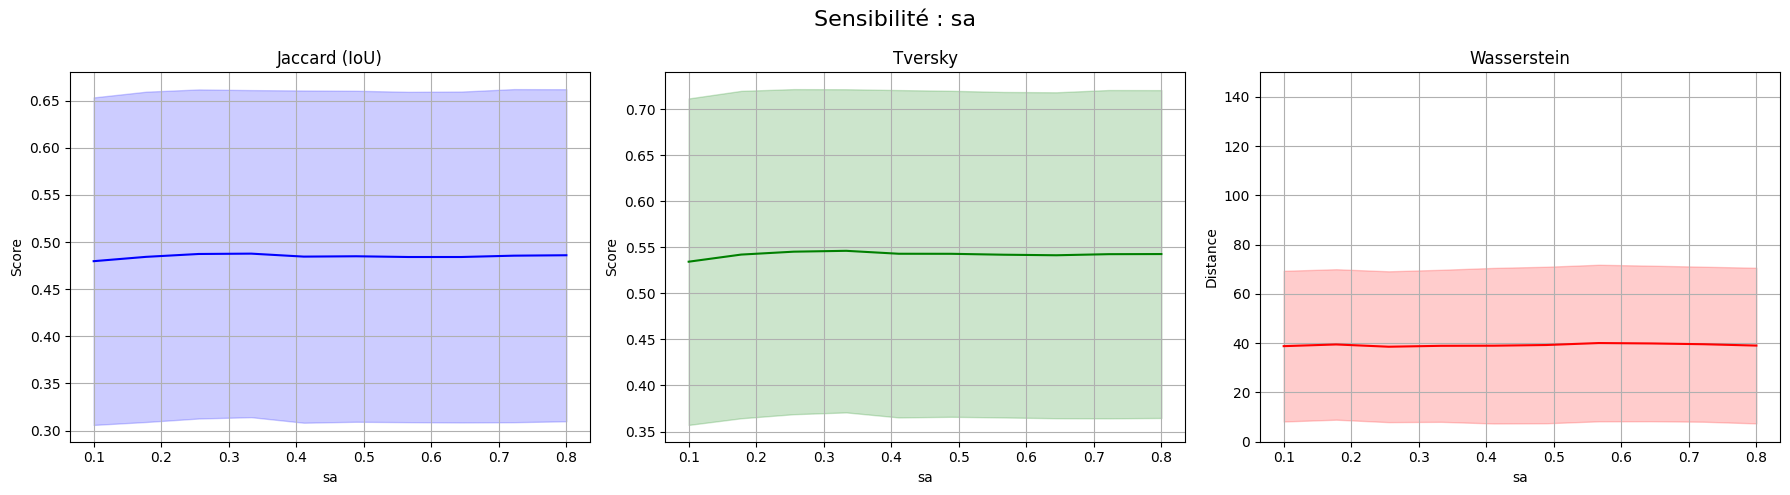


--- Analyse de sensibilité pour τ ---


[τ = 0.05] évalué en 95.35s : Jaccard=0.3121±0.2293 | Tversky=0.3877±0.2562 | Wasserstein=712.0791±1688.7861


[τ = 0.08888888888888889] évalué en 111.64s : Jaccard=0.4253±0.2178 | Tversky=0.4944±0.2259 | Wasserstein=276.1563±883.8642


[τ = 0.12777777777777777] évalué en 118.94s : Jaccard=0.4567±0.2001 | Tversky=0.5218±0.2032 | Wasserstein=134.7425±616.9801


[τ = 0.16666666666666669] évalué en 126.88s : Jaccard=0.4766±0.1821 | Tversky=0.5384±0.1835 | Wasserstein=92.1408±548.2598


...

[τ = 0.24444444444444446] évalué en 135.00s : Jaccard=0.4849±0.1749 | Tversky=0.5389±0.1798 | Wasserstein=38.8601±30.5879


[τ = 0.2833333333333333] évalué en 140.03s : Jaccard=0.4761±0.1726 | Tversky=0.5250±0.1799 | Wasserstein=39.5938±30.1486


[τ = 0.32222222222222224] évalué en 146.30s : Jaccard=0.4600±0.1715 | Tversky=0.5032±0.1808 | Wasserstein=43.3991±31.1319


[τ = 0.3611111111111111] évalué en 153.17s : Jaccard=0.4333±0.1659 | Tversky=0.4682±0.1762 | Wasserstein=47.3230±29.7132


[τ = 0.4] évalué en 158.67s : Jaccard=0.3897±0.1534 | Tversky=0.4168±0.1640 | Wasserstein=54.7900±27.7332
--- Fin de l'analyse pour τ (Temps total : 1316.86s) ---


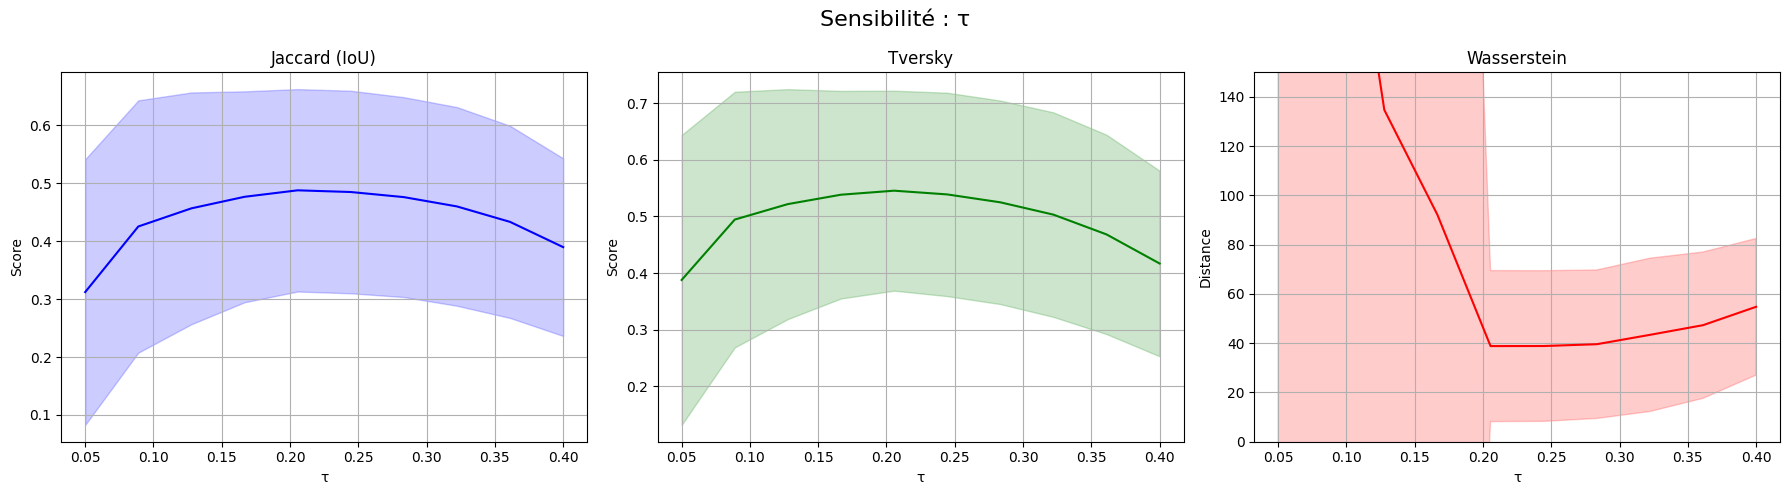


--- Analyse de sensibilité pour τ_c ---


[τ_c = 0.01] évalué en 131.20s : Jaccard=0.4842±0.1722 | Tversky=0.5353±0.1731 | Wasserstein=38.9726±30.4776


[τ_c = 0.015555555555555555] évalué en 130.51s : Jaccard=0.4874±0.1739 | Tversky=0.5420±0.1753 | Wasserstein=38.7842±30.6889


[τ_c = 0.02111111111111111] évalué en 130.46s : Jaccard=0.4881±0.1741 | Tversky=0.5451±0.1758 | Wasserstein=38.8929±31.0302


[τ_c = 0.026666666666666665] évalué en 131.02s : Jaccard=0.4881±0.1741 | Tversky=0.5471±0.1759 | Wasserstein=39.0545±31.0540


...

[τ_c = 0.03777777777777778] évalué en 131.64s : Jaccard=0.4855±0.1736 | Tversky=0.5475±0.1759 | Wasserstein=39.7090±31.0878


[τ_c = 0.04333333333333333] évalué en 131.62s : Jaccard=0.4842±0.1733 | Tversky=0.5475±0.1758 | Wasserstein=39.8075±30.4507


[τ_c = 0.048888888888888885] évalué en 132.75s : Jaccard=0.4828±0.1729 | Tversky=0.5475±0.1755 | Wasserstein=40.4881±30.8273


[τ_c = 0.05444444444444444] évalué en 133.24s : Jaccard=0.4812±0.1726 | Tversky=0.5469±0.1755 | Wasserstein=40.6338±30.5073


[τ_c = 0.06] évalué en 132.43s : Jaccard=0.4798±0.1724 | Tversky=0.5465±0.1755 | Wasserstein=40.9875±30.8113
--- Fin de l'analyse pour τ_c (Temps total : 1316.29s) ---


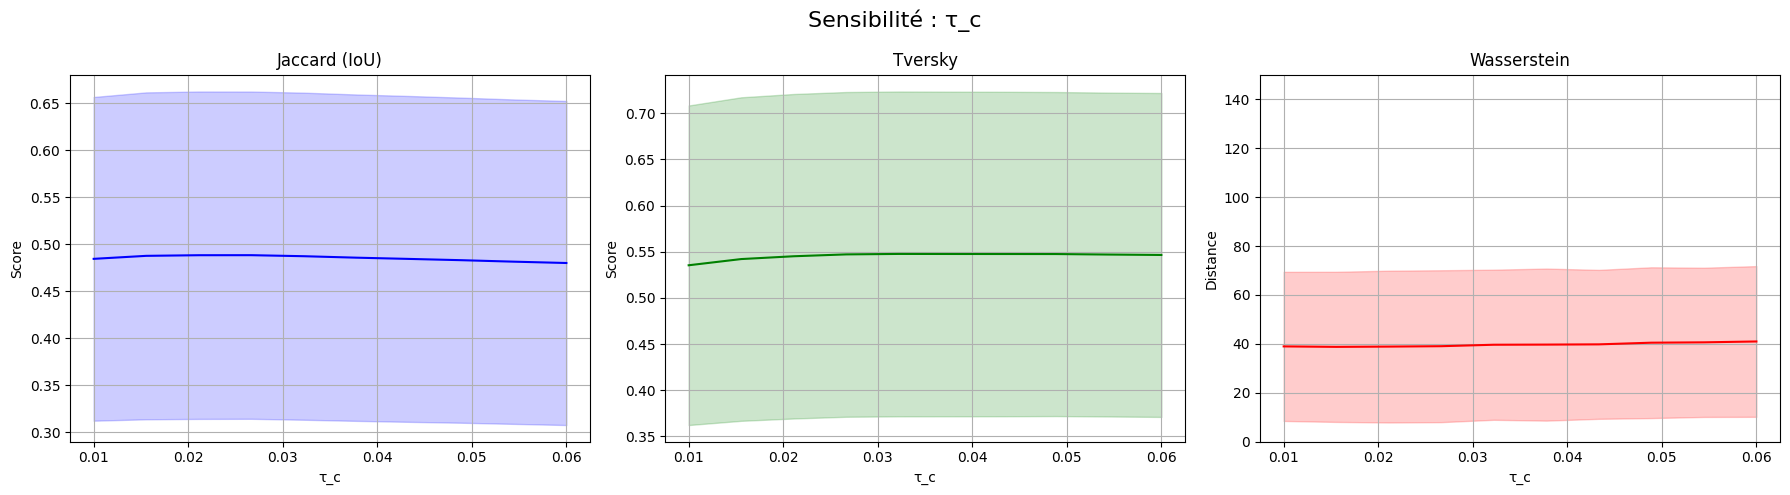


--- Analyse de sensibilité pour σ_0 ---


[σ_0 = 2.0] évalué en 117.53s : Jaccard=0.3853±0.1871 | Tversky=0.4152±0.2000 | Wasserstein=86.2442±246.6135


[σ_0 = 2.888888888888889] évalué en 121.50s : Jaccard=0.4764±0.1931 | Tversky=0.5261±0.2009 | Wasserstein=93.2398±375.1914


[σ_0 = 3.7777777777777777] évalué en 129.98s : Jaccard=0.4887±0.1800 | Tversky=0.5458±0.1828 | Wasserstein=42.7977±35.5212


[σ_0 = 4.666666666666666] évalué en 131.24s : Jaccard=0.4855±0.1777 | Tversky=0.5437±0.1802 | Wasserstein=41.1864±32.8712


...

[σ_0 = 6.444444444444445] évalué en 140.61s : Jaccard=0.4705±0.1643 | Tversky=0.5294±0.1677 | Wasserstein=39.3448±29.3261


[σ_0 = 7.333333333333333] évalué en 144.34s : Jaccard=0.4563±0.1648 | Tversky=0.5126±0.1689 | Wasserstein=41.1266±27.7914


[σ_0 = 8.222222222222221] évalué en 147.11s : Jaccard=0.4332±0.1650 | Tversky=0.4900±0.1703 | Wasserstein=44.2507±32.0593


[σ_0 = 9.11111111111111] évalué en 150.34s : Jaccard=0.4129±0.1583 | Tversky=0.4679±0.1653 | Wasserstein=44.5601±30.6693


[σ_0 = 10.0] évalué en 150.71s : Jaccard=0.3941±0.1589 | Tversky=0.4508±0.1655 | Wasserstein=49.0287±35.0944
--- Fin de l'analyse pour σ_0 (Temps total : 1370.45s) ---


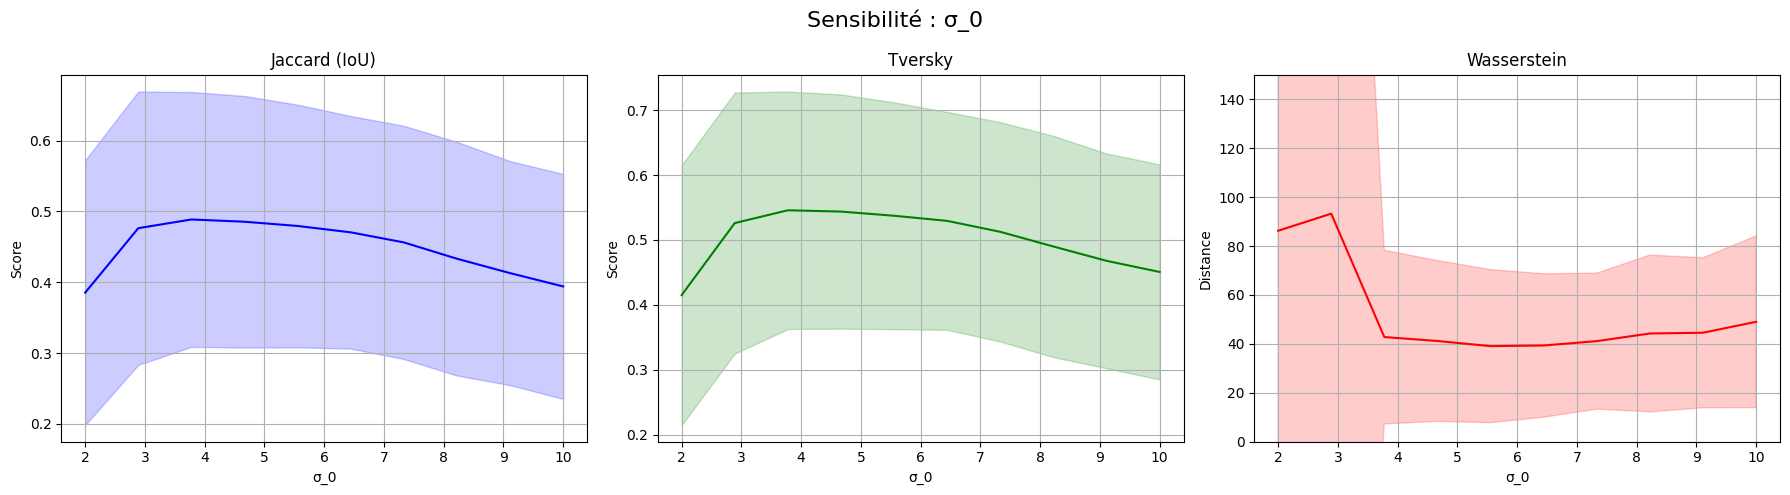


--- Analyse de sensibilité pour min_rel_size ---


[min_rel_size = 50.0] évalué en 118.62s : Jaccard=0.4143±0.2312 | Tversky=0.4739±0.2472 | Wasserstein=489.6340±1209.2672


[min_rel_size = 88.88888888888889] évalué en 126.73s : Jaccard=0.4710±0.1987 | Tversky=0.5318±0.2045 | Wasserstein=177.5780±653.7276


[min_rel_size = 127.77777777777777] évalué en 131.49s : Jaccard=0.4861±0.1773 | Tversky=0.5467±0.1775 | Wasserstein=40.7125±32.8137


[min_rel_size = 166.66666666666666] évalué en 131.55s : Jaccard=0.4897±0.1747 | Tversky=0.5469±0.1772 | Wasserstein=38.4613±30.7966


...

[min_rel_size = 244.44444444444443] évalué en 133.44s : Jaccard=0.4756±0.1642 | Tversky=0.5240±0.1690 | Wasserstein=39.5263±28.7509


[min_rel_size = 283.3333333333333] évalué en 132.68s : Jaccard=0.4588±0.1601 | Tversky=0.5024±0.1659 | Wasserstein=42.3537±28.6437


[min_rel_size = 322.2222222222222] évalué en 133.71s : Jaccard=0.4456±0.1543 | Tversky=0.4847±0.1605 | Wasserstein=45.4488±28.4734


[min_rel_size = 361.1111111111111] évalué en 134.12s : Jaccard=0.4278±0.1490 | Tversky=0.4632±0.1561 | Wasserstein=47.6406±27.3191


[min_rel_size = 400.0] évalué en 135.99s : Jaccard=0.4055±0.1438 | Tversky=0.4370±0.1519 | Wasserstein=51.0760±27.8280
--- Fin de l'analyse pour min_rel_size (Temps total : 1311.19s) ---


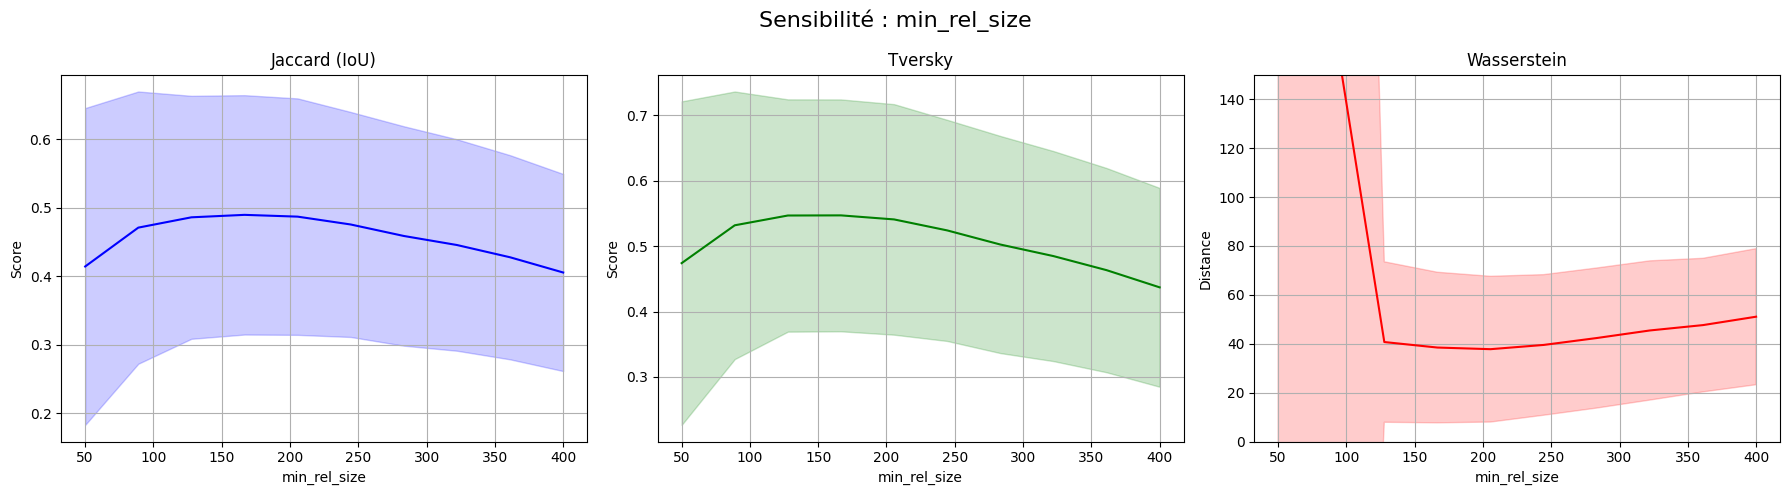

In [6]:
import copy
from tqdm import tqdm
import pandas as pd

print("Chargement complet des 118 images en RAM pour accélérer l'analyse de sensibilité...")
all_data = []
for i in range(len(dataset)):
    all_data.append(dataset[i])
print("Terminé.")

default_params = {
    'R': 5,
    'ss': 1.0,
    'si': 0.25,
    'sa': 0.3,
    'τ': 0.2,
    'σ_0': 5.0,
    'τ_c': 0.025,
    'min_rel_size': 150.0
}

# nb_pas = 10
param_ranges = {
    'R': np.linspace(1, 10, 10, dtype=int).tolist(),
    'ss': np.linspace(0.5, 2.5, 10).tolist(),
    'si': np.linspace(0.1, 0.9, 10).tolist(),
    'sa': np.linspace(0.1, 0.8, 10).tolist(),
    'τ': np.linspace(0.05, 0.4, 10).tolist(),
    'τ_c': np.linspace(0.01, 0.06, 10).tolist(),
    'σ_0': np.linspace(2.0, 10.0, 10).tolist(),
    'min_rel_size': np.linspace(50.0, 400.0, 10).tolist()
}

os.makedirs("sensitivity_results", exist_ok=True)

def evaluate_dataset(params):
    import time
    j_list, t_list, w_list = [], [], []
    individual_results = []

    sigma_val = params['σ_0']

    for sample in tqdm(all_data, desc=f"Éval images (Σ={sigma_val:.1f}, R={params['R']}, ss={params['ss']:.2f}, si={params['si']:.2f}, sa={params['sa']:.2f}, τ={params['τ']:.2f}, τ_c={params['τ_c']:.3f}, min_rel_size={params['min_rel_size']:.1f})", leave=False):
        imgs_i = {'visible': sample['visible']}
        weights_i = {'visible': 1.0}

        _, _, centrality_i, _, _ = extract_frangi_graph_gpu(
            imgs_i, weights_i,
            Σ=[sigma_val],
            R=int(params['R']),
            ss=params['ss'],
            si=params['si'],
            sa=params['sa'],
            τ=params['τ'],
            min_rel_size=params['min_rel_size'],
            device=device
        )

        pred_i = (centrality_i > params['τ_c']).astype(np.uint8)
        sk_pred_thick_i = thicken(pred_i, pixels=3)

        gt_arr_i = sample['gt'].numpy().astype(np.uint8)
        sk_gt_i = skeletonize_lee(gt_arr_i)
        sk_gt_thick_i = thicken(sk_gt_i, pixels=3)

        j, t = compute_metrics(sk_pred_thick_i, sk_gt_thick_i)
        w = wasserstein_distance_skeletons(sk_pred_thick_i, sk_gt_thick_i)

        j_list.append(j)
        t_list.append(t)
        w_list.append(w)
        individual_results.append({
            'ID': sample['id'],
            'Jaccard': j,
            'Tversky': t,
            'Wasserstein': w
        })

    return np.mean(j_list), np.std(j_list), np.mean(t_list), np.std(t_list), np.mean(w_list), np.std(w_list), individual_results

import time
for param_name, values in param_ranges.items():
    print(f"\n{'='*60}\n--- Analyse de sensibilité pour {param_name} ---\n{'='*60}")
    results_summary = []
    all_individual_results = []

    t0_param = time.time()

    for val in values:
        t0_val = time.time()

        current_params = copy.deepcopy(default_params)
        current_params[param_name] = val

        j_mean, j_std, t_mean, t_std, w_mean, w_std, ind_res = evaluate_dataset(current_params)

        t_val = time.time() - t0_val
        print(f"[{param_name} = {val}] évalué en {t_val:.2f}s : Jaccard={j_mean:.4f}±{j_std:.4f} | Tversky={t_mean:.4f}±{t_std:.4f} | Wasserstein={w_mean:.4f}±{w_std:.4f}")

        results_summary.append({
            param_name: val,
            'Jaccard_mean': j_mean, 'Jaccard_std': j_std,
            'Tversky_mean': t_mean, 'Tversky_std': t_std,
            'Wasserstein_mean': w_mean, 'Wasserstein_std': w_std
        })

        for res in ind_res:
            res_copy = res.copy()
            res_copy[param_name] = val
            all_individual_results.append(res_copy)

    t_param = time.time() - t0_param
    print(f"--- Fin de l'analyse pour {param_name} (Temps total : {t_param:.2f}s) ---")

    # Sauvegarde CSV
    df_summary = pd.DataFrame(results_summary)
    df_summary.to_csv(f"sensitivity_results/summary_{param_name}.csv", index=False)

    df_ind = pd.DataFrame(all_individual_results)
    df_ind.to_csv(f"sensitivity_results/individual_{param_name}.csv", index=False)

    # Affichage des 3 jolies courbes
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Sensibilité : {param_name}", fontsize=16)

    x_vals = df_summary[param_name]

    # Jaccard
    axes[0].plot(x_vals, df_summary['Jaccard_mean'], 'b-', label='Jaccard')
    axes[0].fill_between(x_vals,
                         df_summary['Jaccard_mean'] - df_summary['Jaccard_std'],
                         df_summary['Jaccard_mean'] + df_summary['Jaccard_std'],
                         color='b', alpha=0.2)
    axes[0].set_title('Jaccard (IoU)')
    axes[0].set_xlabel(param_name)
    axes[0].set_ylabel('Score')
    axes[0].grid(True)

    # Tversky
    axes[1].plot(x_vals, df_summary['Tversky_mean'], 'g-', label='Tversky')
    axes[1].fill_between(x_vals,
                         df_summary['Tversky_mean'] - df_summary['Tversky_std'],
                         df_summary['Tversky_mean'] + df_summary['Tversky_std'],
                         color='g', alpha=0.2)
    axes[1].set_title('Tversky')
    axes[1].set_xlabel(param_name)
    axes[1].set_ylabel('Score')
    axes[1].grid(True)

    # Wasserstein
    axes[2].plot(x_vals, df_summary['Wasserstein_mean'], 'r-', label='Wasserstein')
    axes[2].fill_between(x_vals,
                         df_summary['Wasserstein_mean'] - df_summary['Wasserstein_std'],
                         df_summary['Wasserstein_mean'] + df_summary['Wasserstein_std'],
                         color='r', alpha=0.2)
    axes[2].set_title('Wasserstein')
    axes[2].set_xlabel(param_name)
    axes[2].set_ylabel('Distance')
    axes[2].set_ylim(0, 150)
    axes[2].grid(True)

    plt.tight_layout()
    plt.savefig(f"sensitivity_results/plot_{param_name}.png")
    plt.show()
